<a href="https://colab.research.google.com/github/ak-sangal/sd-extension-chainner/blob/main/Z-Image%20With%20_Lora%20Support.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background-color: #161b22; padding: 20px; border-radius: 12px; border-left: 6px solid #2ecc71; box-shadow: 0 4px 6px rgba(0,0,0,0.3);">
  <h1 style="color: #ffffff; margin: 0; font-family: sans-serif; font-weight: 700; letter-spacing: 1px;">
    ⚡ Z-Image Turbo <span style="font-size: 0.6em; color: #2ecc71; vertical-align: middle; background: #2ecc7122; padding: 2px 8px; border-radius: 6px;">With Lora Support</span>
  </h1>
  <p style="color: #8b949e; margin: 8px 0 0 0; font-family: sans-serif;">
    • Hybrid FP8/GGUF + LoRA Optimized
  </p>
</div>

### 🔴 **Brought to you by [AI With Chucky](https://youtube.com/@AIWithChucky)**
*Subscribe for more AI tutorials, workflows, and optimization tips!*

In [1]:
#@title 1. Initialize Core Environment
#@markdown This prepares the ephemeral storage, installs ComfyUI, and configures the GGUF integration tools.

import os
import subprocess

LOCAL_WORKSPACE = "/content/ComfyUI"

print("🚀 Initializing Core Architecture...")
if not os.path.exists(LOCAL_WORKSPACE):
    !git clone https://github.com/comfyanonymous/ComfyUI {LOCAL_WORKSPACE} &> /dev/null
    print("   ✓ Core Engine Cloned")
else:
    !cd {LOCAL_WORKSPACE} && git pull &> /dev/null
    print("   ✓ Core Engine Updated")

print("📦 Installing Dependencies (This takes a moment)...")
!cd {LOCAL_WORKSPACE} && pip install xformers!=0.0.18 -r requirements.txt --extra-index-url https://download.pytorch.org/whl/cu121 &> /dev/null

GGUF_NODE_DIR = os.path.join(LOCAL_WORKSPACE, "custom_nodes/ComfyUI-GGUF")
if not os.path.exists(GGUF_NODE_DIR):
    print("🧩 Installing GGUF Processing Nodes...")
    !git clone https://github.com/city96/ComfyUI-GGUF {GGUF_NODE_DIR} &> /dev/null
    !pip install -r {GGUF_NODE_DIR}/requirements.txt &> /dev/null

print("✅ Environment Ready!")

🚀 Initializing Core Architecture...
   ✓ Core Engine Cloned
📦 Installing Dependencies (This takes a moment)...
🧩 Installing GGUF Processing Nodes...
✅ Environment Ready!


In [13]:
#@title 2. High-Speed Asset Downloader
#@markdown Paste your HuggingFace/Civitai model links here. The required Z-Image base assets (Qwen Text Encoder & VAE) are automatically fetched.

import os
import subprocess
import gdown
import urllib.parse

WORKSPACE = "/content/ComfyUI"

# --- Input Resources ---
UNET_URLS = "https://huggingface.co/unsloth/Z-Image-Turbo-GGUF/resolve/main/z-image-turbo-Q8_0.gguf" #@param {type:"string"}
LORA_URLS = "https://huggingface.co/Amberamberamber/NSFW_master_ZIT_000017532/resolve/main/NSFW_master_ZIT_000017532.safetensors" #@param {type:"string"}

# Pre-configured required models
TEXT_ENCODER_URLS = "https://huggingface.co/Comfy-Org/z_image_turbo/resolve/main/split_files/text_encoders/qwen_3_4b.safetensors"
VAE_URLS = "https://huggingface.co/Comfy-Org/z_image_turbo/resolve/main/split_files/vae/ae.safetensors"

DIRS = {
    "unet":           os.path.join(WORKSPACE, "models/unet"),
    "clip":           os.path.join(WORKSPACE, "models/clip"),
    "vae":            os.path.join(WORKSPACE, "models/vae"),
    "loras":          os.path.join(WORKSPACE, "models/loras"),
}

print("⚡ Configuring Aria2c Accelerator...")
subprocess.run(['apt-get', '-y', 'install', '-qq', 'aria2'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

def download_file(url, target_dir):
    try:
        os.makedirs(target_dir, exist_ok=True)
        before_files = set(os.listdir(target_dir))

        if "drive.google.com" in url:
            print(f"   📥 Downloading from Drive...")
            gdown.download(url, output=target_dir + '/', quiet=False, fuzzy=True)
        else:
            print(f"   📥 Fetching: {url.split('/')[-1][:40]}...")
            parsed_url = urllib.parse.urlparse(url)
            filename = os.path.basename(parsed_url.path)

            aria2_cmd = [
                "aria2c", "--console-log-level=error", "--summary-interval=10",
                "-c", "-x", "16", "-s", "16", "-k", "1M"
            ]

            if "civitai.com" in url:
                aria2_cmd.extend(["--content-disposition", url, "-d", target_dir])
            elif filename:
                aria2_cmd.extend(["-o", filename, url, "-d", target_dir])
            else:
                aria2_cmd.extend(["--content-disposition", url, "-d", target_dir])

            subprocess.run(aria2_cmd, check=True)

        after_files = set(os.listdir(target_dir))
        new_files = after_files - before_files

        if new_files:
            downloaded_file = list(new_files)[0]
            print(f"   ✅ Saved as: \033[96m{downloaded_file}\033[0m")
        else:
            print(f"   ✅ Download complete (Overwrote existing file)")

    except Exception as e:
        print(f"   ❌ Failed: {url}\n      Error: {e}\n")

def process_downloads(urls_str, target_dir):
    if not urls_str.strip(): return
    url_list = [u.strip() for u in urls_str.replace(',', '\n').split('\n') if u.strip()]
    os.makedirs(target_dir, exist_ok=True)
    print(f"\n📂 Directory: {os.path.basename(target_dir)}")
    for url in url_list:
        download_file(url, target_dir)

process_downloads(UNET_URLS,         DIRS["unet"])
process_downloads(LORA_URLS,         DIRS["loras"])
process_downloads(TEXT_ENCODER_URLS, DIRS["clip"])
process_downloads(VAE_URLS,          DIRS["vae"])

print("\n✅ All assets secured!")

⚡ Configuring Aria2c Accelerator...

📂 Directory: unet
   📥 Fetching: z-image-turbo-Q8_0.gguf...
   ✅ Download complete (Overwrote existing file)

📂 Directory: loras
   📥 Fetching: NSFW_master_ZIT_000017532.safetensors...
   ✅ Download complete (Overwrote existing file)

📂 Directory: clip
   📥 Fetching: qwen_3_4b.safetensors...
   ✅ Download complete (Overwrote existing file)

📂 Directory: vae
   📥 Fetching: ae.safetensors...
   ✅ Download complete (Overwrote existing file)

✅ All assets secured!


🔌 Checking ComfyUI Server Status...
   🟢 Server is already running.
➜ Generation Details | Size: 832x832 | Seed: 286533433361075
   📥 Submitting workflow to API...
   ✨ Processing and Sampling (Check ComfyUI server logs if stuck)...
   🖼️ Decoding Final Masterpiece...
✓ Saved: z-image_00010_.png


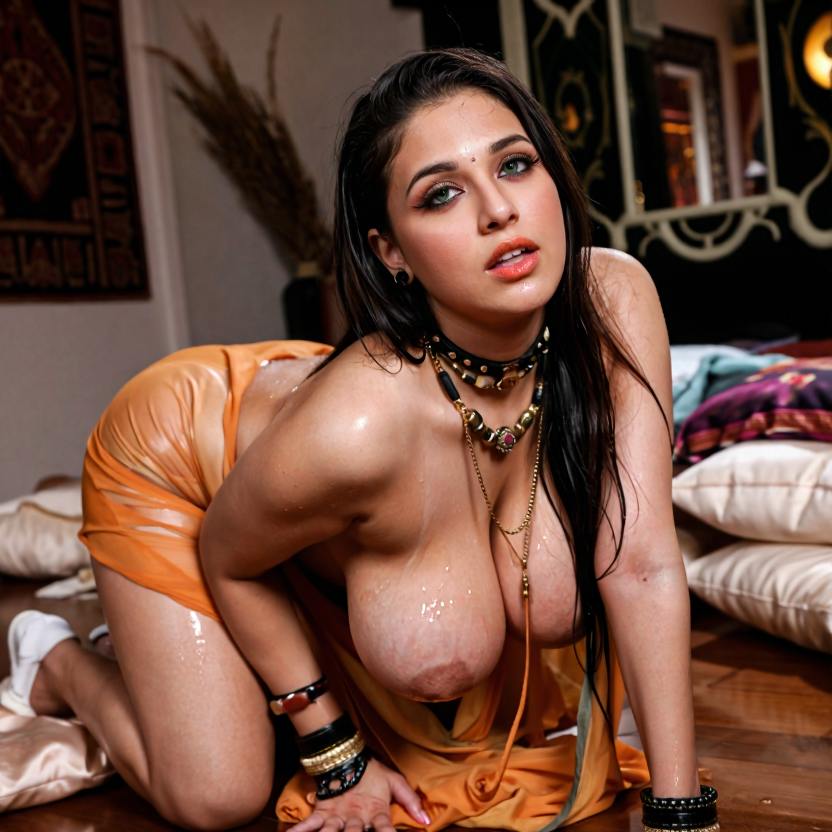

✓ Saved: z-image_00011_.png


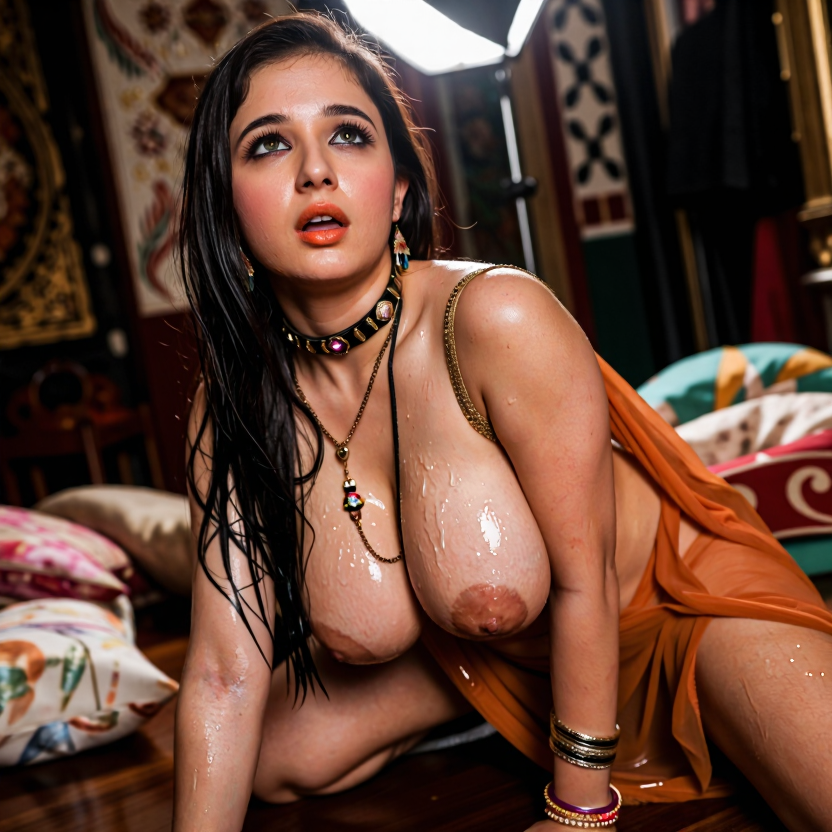

✓ Saved: z-image_00012_.png


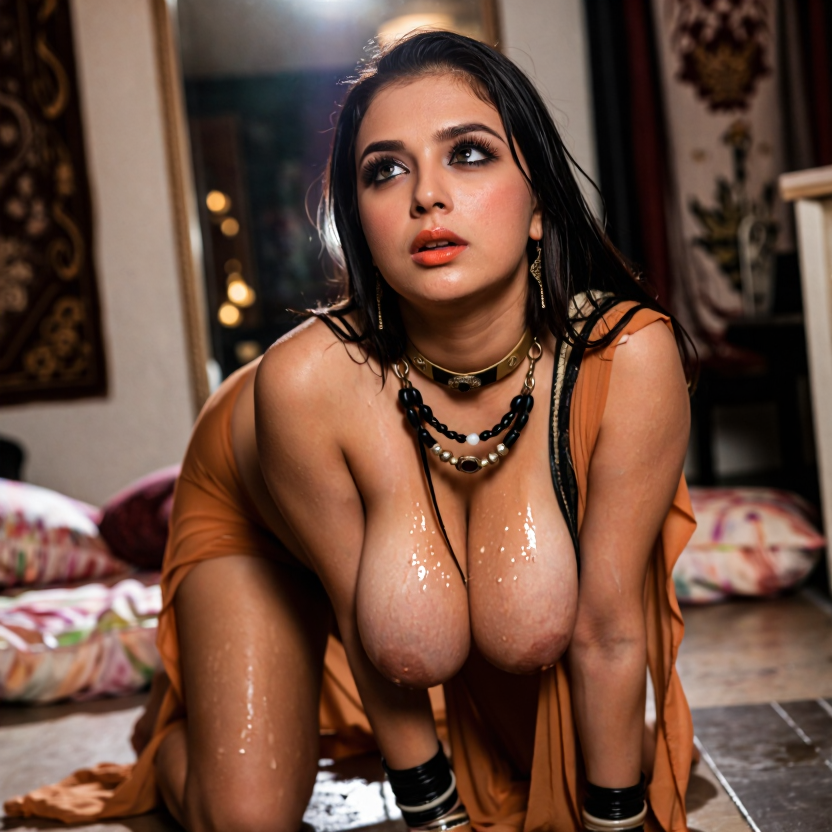

✓ Saved: z-image_00013_.png


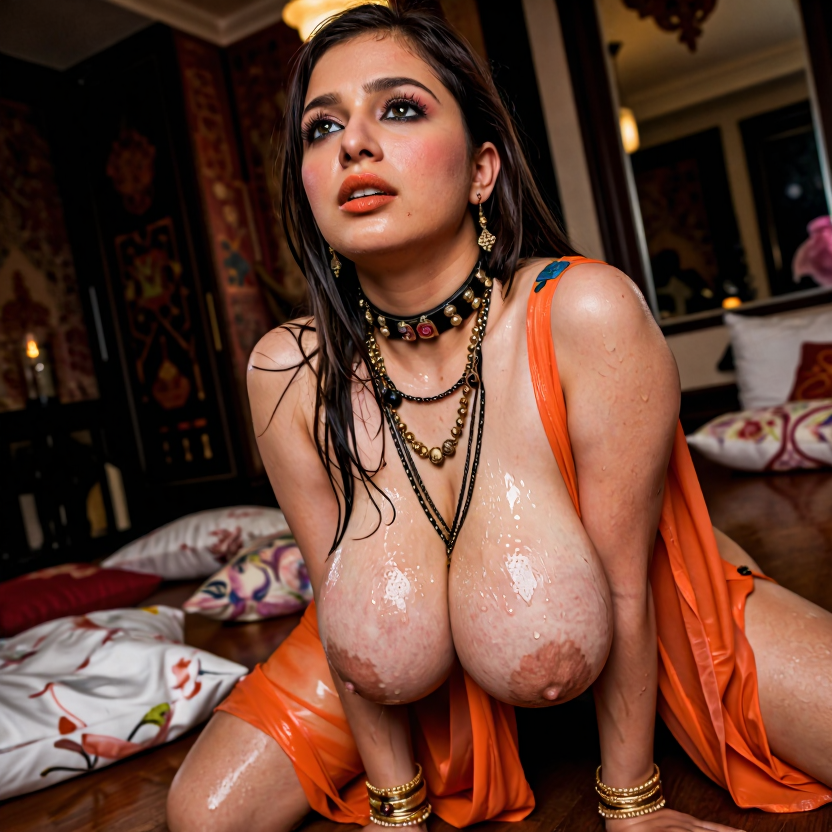

In [14]:
#@title 3. Image Generation
#@markdown Enter your prompt and tweak parameters.

# --- Model Selection ---
UNET_FILENAME = "z-image-turbo-Q8_0.gguf" #@param {type:"string"}
LORA_FILENAME = "NSFW_master_ZIT_000017532.safetensors" #@param {type:"string"}
LORA_STRENGTH = 1 #@param {type:"slider", min:0.0, max:2.0, step:0.05}

# --- Generation Settings ---
PROMPT = "(sexy:55), (explicit content:55). 超高清, 极致细节, 电影感, 真实感爆棚, 顶级画质, 光影大师, 细腻皮肤, 质感拉满   #Subject - A sexy Indian woman with huge tits, embodying a wet look, is kneeling on the floor and posing seductively as if preparing for a blow job, her posture arched forward with parted lips and an inviting gaze directed upward toward an implied viewer.  #Composition - The main subject is centered in the foreground, occupying the lower two-thirds of the frame for emphasis on her kneeling pose and exposed upper body; her sheer see-through saree drapes loosely around her hips and legs, with jewelry and leather collar adding focal points around her neck and wrists; the composition uses a low-angle perspective to highlight her huge tits and facial features, creating a sense of intimacy and dominance.  #Background - Subtle elements include a dimly lit bedroom setting with soft silk cushions scattered on a polished wooden floor, faint outlines of ornate Indian tapestries on the walls, and a large mirror reflecting part of the scene in the distant background.  #Lighting - Soft, warm ambient lighting from overhead sources casts gentle highlights on her wet skin and sheer saree, creating subtle glistening effects and soft shadows that accentuate her curves and huge tits without harsh contrasts.  #Keywords - sexy Indian girl, huge tits, wet look, sheer see-through saree, without any blouse, topless, showing tits, orange lipstick, green eye kajal mascara, jewellery, leather collar, kneeling on the floor, posing for a blow job, seductive pose, intimate bedroom.  #Appearance of a Subject - The subject has a voluptuous Indian physique with tanned skin, long dark hair cascading wetly over her shoulders, huge exposed tits glistening with a wet sheen; she wears a sheer see-through orange saree draped translucently over her lower body without any blouse, making her topless and showing tits clearly; makeup includes vibrant orange lipstick on full lips and green eye kajal mascara enhancing her almond-shaped eyes; accessories feature intricate gold jewellery such as earrings, bangles, and necklaces, paired with a black leather collar around her neck for a submissive edge.  #Style - Realistic digital art in high-resolution 4K with photorealistic details, using hyper-detailed textures for skin, fabric transparency, and wet effects, rendered in a cinematic style with depth of field to blur the background slightly, evoking professional erotic photography.  #Mood - Sensual and provocative, with an air of teasing submission and erotic anticipation.   (NSFW:55). #masterpiece, best quality, very aesthetic, uwu_clarity. #You are an assistant in explicit imagery depicting sexual content. realistic side lighting, realistic soft lighting. #Bright light illuminates the scene from above, casting harsh, defined shadows. #extremely detailed, ultra-detailed, masterpiece, 8K, uhd, best quality, high resolution. sharp image, extremely detailed, ultra-detailed, masterpiece, 8K, uhd, best quality, high resolution, #captured as a high-resolution digital photograph taken with a Canon EOS R5." #@param {type:"string"}
NEGATIVE_PROMPT = "blurry, low quality, deformed, artifacts" #@param {type:"string"}
WIDTH = 832 #@param {type:"slider", min:512, max:2048, step:64}
HEIGHT = 832 #@param {type:"slider", min:512, max:2048, step:64}
BATCH_SIZE = 4 #@param {type:"slider", min:1, max:4, step:1}

# --- Advanced Sampler Settings ---
STEPS = 9 #@param {type:"slider", min:1, max:20, step:1}
CFG = 1.0 #@param {type:"number"}
SAMPLER_NAME = "res_multistep" #@param ["euler", "euler_ancestral", "heun", "dpm_2", "dpm_2_ancestral", "lms", "dpm_fast", "dpm_adaptive", "dpmpp_2s_ancestral", "dpmpp_sde", "dpmpp_sde_gpu", "dpmpp_2m", "dpmpp_2m_sde", "dpmpp_2m_sde_gpu", "dpmpp_3m_sde", "dpmpp_3m_sde_gpu", "ddpm", "lcm", "ddim", "uni_pc", "uni_pc_bh2", "res_multistep"] {allow-input: true}
SCHEDULER = "beta" #@param ["normal", "karras", "exponential", "sgm_uniform", "simple", "ddim_uniform", "beta"] {allow-input: true}
AURA_SHIFT = 3.0 #@param {type:"slider", min:1.0, max:10.0, step:0.5}
SEED = 0 #@param {type:"integer"}

import sys
import os
import json
import time
import random
import subprocess
import urllib.request
from IPython.display import display, Image as IPImage

WORKSPACE = "/content/ComfyUI"
os.chdir(WORKSPACE)

if SEED == 0:
    SEED = random.randint(1, 1125899906842624)

print("🔌 Checking ComfyUI Server Status...")
def start_server():
    req = urllib.request.Request("http://127.0.0.1:8188")
    try:
        urllib.request.urlopen(req)
        print("   🟢 Server is already running.")
    except:
        print("   🚀 Starting ComfyUI Server in background...")
        subprocess.Popen([sys.executable, "main.py"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        while True:
            try:
                urllib.request.urlopen(req)
                print("   🟢 Server is now up and ready!")
                break
            except:
                time.sleep(2)

start_server()
print(f"\033[94m➜ Generation Details | Size: {WIDTH}x{HEIGHT} | Seed: {SEED}\033[0m")

prompt_workflow = {
    "9": {"inputs": {"filename_prefix": "z-image", "images": ["43", 0]}, "class_type": "SaveImage"},
    "39": {"inputs": {"clip_name": "qwen_3_4b.safetensors", "type": "lumina2", "device": "default"}, "class_type": "CLIPLoader"},
    "40": {"inputs": {"vae_name": "ae.safetensors"}, "class_type": "VAELoader"},
    "41": {"inputs": {"width": WIDTH, "height": HEIGHT, "batch_size": BATCH_SIZE}, "class_type": "EmptySD3LatentImage"},
    "42": {"inputs": {"text": NEGATIVE_PROMPT, "clip": ["39", 0]}, "class_type": "CLIPTextEncode"},
    "43": {"inputs": {"samples": ["44", 0], "vae": ["40", 0]}, "class_type": "VAEDecode"},
    "44": {"inputs": {"seed": SEED, "steps": STEPS, "cfg": CFG, "sampler_name": SAMPLER_NAME, "scheduler": SCHEDULER, "denoise": 1, "model": ["47", 0], "positive": ["45", 0], "negative": ["42", 0], "latent_image": ["41", 0]}, "class_type": "KSampler"},
    "45": {"inputs": {"text": PROMPT, "clip": ["39", 0]}, "class_type": "CLIPTextEncode"},
    "47": {"inputs": {"shift": AURA_SHIFT, "model": ["50", 0]}, "class_type": "ModelSamplingAuraFlow"},
    "50": {"inputs": {"lora_name": LORA_FILENAME, "strength_model": LORA_STRENGTH, "model": ["48", 0]}, "class_type": "LoraLoaderModelOnly"}
}

# Smart UNet Node Routing based on file extension
if UNET_FILENAME.lower().endswith('.gguf'):
    prompt_workflow["48"] = {"inputs": {"unet_name": UNET_FILENAME}, "class_type": "UnetLoaderGGUF"}
else:
    prompt_workflow["48"] = {"inputs": {"unet_name": UNET_FILENAME, "weight_dtype": "default"}, "class_type": "UNETLoader"}

# LoRA Bypass Routing
if not LORA_FILENAME.strip() or LORA_FILENAME.lower() == "none":
    prompt_workflow["47"]["inputs"]["model"] = ["48", 0]
    if "50" in prompt_workflow:
        del prompt_workflow["50"]

p = {"prompt": prompt_workflow}
data = json.dumps(p).encode('utf-8')
req = urllib.request.Request("http://127.0.0.1:8188/prompt", data=data)

print("   📥 Submitting workflow to API...")
try:
    response = urllib.request.urlopen(req)
    prompt_id = json.loads(response.read())['prompt_id']
except Exception as e:
    print(f"   ❌ API Error: {e}")
    raise

print("   ✨ Processing and Sampling (Check ComfyUI server logs if stuck)...")
while True:
    try:
        history_req = urllib.request.Request(f"http://127.0.0.1:8188/history/{prompt_id}")
        history_res = urllib.request.urlopen(history_req)
        history_data = json.loads(history_res.read())
        if prompt_id in history_data:
            outputs = history_data[prompt_id]['outputs']
            break
    except:
        pass
    time.sleep(1)

print("   🖼️ Decoding Final Masterpiece...")
for node_id, node_output in outputs.items():
    if 'images' in node_output:
        for image in node_output['images']:
            filename = image['filename']
            img_path = os.path.join(WORKSPACE, "output", filename)
            print(f"\033[92m✓ Saved: {filename}\033[0m")
            display(IPImage(filename=img_path))

In [15]:
 #@title 4. Export & Download Results
#@markdown Run this to instantly zip and download all the generated images from this session.

import os
from google.colab import files

OUTPUT_DIR = "/content/ComfyUI/output"
ZIP_NAME = "/content/Z_Image_Artworks.zip"

if os.path.exists(OUTPUT_DIR) and len(os.listdir(OUTPUT_DIR)) > 0:
    print("🗜️ Zipping generated artworks...")
    !zip -j -q {ZIP_NAME} {OUTPUT_DIR}/*.png
    print("📥 Initiating download...")
    files.download(ZIP_NAME)
else:
    print("⚠️ No images found in the output directory yet!")

🗜️ Zipping generated artworks...
📥 Initiating download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>